# Behler-Parrinello Symmetry Functions

This notebook demonstrates atom-centered symmetry functions (ACSFs), which are
smooth, many-body descriptors commonly used as input features for neural network
potentials.

**Reference**: Behler & Parrinello, PRL 98, 146401 (2007)

Two main types:
- **G2** (radial): Encodes distance information via Gaussian functions
- **G4** (angular): Encodes three-body angular information

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk, molecule
import pyscal3

## 1. Basic Usage

In [2]:
# Create FCC copper
atoms = bulk("Cu", "fcc", cubic=True).repeat(3)

# Find neighbors (cutoff must cover ACSF cutoff)
pyscal3.find_neighbors(atoms, method="cutoff", cutoff=6.0)

# Compute symmetry functions
result = pyscal3.symmetry_functions(atoms, cutoff=6.0)

print(f"Number of atoms: {len(atoms)}")
print(f"Feature vector shape: {result['features'].shape}")
print(f"G2 features: {result['G2'].shape[1]}")
print(f"G4 features: {result['G4'].shape[1]}")

Number of atoms: 108
Feature vector shape: (108, 16)
G2 features: 8
G4 features: 8


## 2. G2 Radial Functions

$G_2^i = \sum_{j \neq i} e^{-\eta(R_{ij} - R_s)^2} \cdot f_c(R_{ij})$

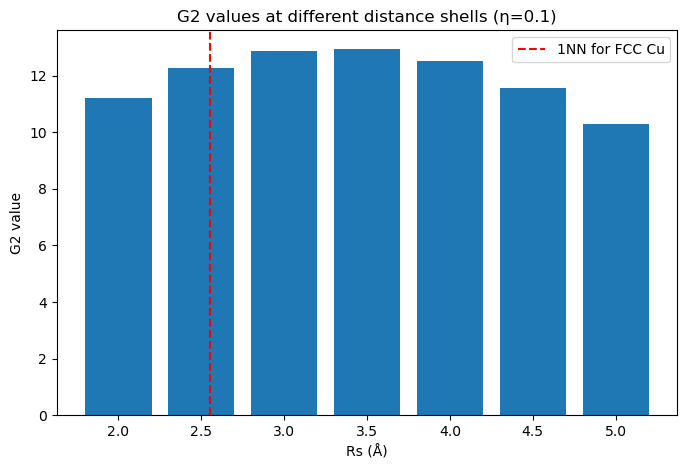


G2 peaks near the 1st neighbor distance (≈2.55 Å for FCC Cu)


In [3]:
# Explore G2 parameters
# eta: Gaussian width (smaller = broader)
# Rs: Gaussian center (shifts the peak location)

# Simple test: vary Rs to probe different distance shells
g2_params = [(0.1, r) for r in [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]]

result = pyscal3.symmetry_functions(
    atoms, cutoff=6.0,
    g2_params=g2_params,
    g4_params=[]  # Skip G4 for this example
)

# Plot G2 values vs Rs for first atom
rs_values = [p[1] for p in g2_params]
g2_vals = result['G2'][0]

plt.figure(figsize=(8, 5))
plt.bar(rs_values, g2_vals, width=0.4)
plt.xlabel('Rs (Å)')
plt.ylabel('G2 value')
plt.title('G2 values at different distance shells (η=0.1)')
plt.axvline(x=2.55, color='r', linestyle='--', label='1NN for FCC Cu')
plt.legend()
plt.show()

print("\nG2 peaks near the 1st neighbor distance (≈2.55 Å for FCC Cu)")

## 3. G4 Angular Functions

$G_4^i = 2^{1-\zeta} \sum_{j < k} (1 + \lambda \cos\theta_{ijk})^\zeta \cdot e^{-\eta(R_{ij}^2 + R_{ik}^2 + R_{jk}^2)} \cdot f_c(R_{ij}) \cdot f_c(R_{ik}) \cdot f_c(R_{jk})$

In [4]:
# G4 parameters:
# eta: radial decay
# zeta: angular resolution (higher = sharper peaks)
# lambda: +1 prefers 0°, -1 prefers 180°

# Compare λ=+1 vs λ=-1
g4_params = [
    (0.01, 2, 1),   # λ=+1
    (0.01, 2, -1),  # λ=-1
]

result = pyscal3.symmetry_functions(
    atoms, cutoff=6.0,
    g2_params=[],
    g4_params=g4_params
)

print("G4 values for first atom:")
print(f"  λ=+1: {result['G4'][0, 0]:.4f}")
print(f"  λ=-1: {result['G4'][0, 1]:.4f}")
print("\nFCC has 60°/90°/120° angles between neighbors")

G4 values for first atom:
  λ=+1: 17.4870
  λ=-1: 3.3513

FCC has 60°/90°/120° angles between neighbors


## 4. Structure Fingerprinting

In [5]:
# Create different structures
fcc = bulk("Cu", "fcc", a=3.6, cubic=True).repeat(3)
bcc = bulk("Cu", "bcc", a=2.87, cubic=True).repeat(3)
hcp = bulk("Ti", "hcp", a=2.95, c=4.68).repeat([3, 3, 2])

structures = {'FCC': fcc, 'BCC': bcc, 'HCP': hcp}

# Compute fingerprints
fingerprints = {}
for name, atoms in structures.items():
    pyscal3.find_neighbors(atoms, method="cutoff", cutoff=6.0)
    result = pyscal3.symmetry_functions(atoms, cutoff=6.0)
    # Mean fingerprint (all atoms equivalent)
    fingerprints[name] = np.mean(result['features'], axis=0)

# Compare fingerprints
print("Fingerprint comparison (Euclidean distance):")
for n1 in structures:
    for n2 in structures:
        if n2 > n1:
            dist = np.linalg.norm(fingerprints[n1] - fingerprints[n2])
            print(f"  {n1} vs {n2}: {dist:.3f}")

Fingerprint comparison (Euclidean distance):
  FCC vs HCP: 34.340
  BCC vs FCC: 1.221
  BCC vs HCP: 33.143


## 5. Multi-Element Systems

In [6]:
# Create NaCl rocksalt structure
nacl = bulk("NaCl", crystalstructure="rocksalt", a=5.64, cubic=True).repeat(2)
pyscal3.find_neighbors(nacl, method="cutoff", cutoff=6.0)

result = pyscal3.symmetry_functions(nacl, cutoff=6.0)

print(f"Element types: {result['element_types']}")
print(f"Feature dimension: {result['features'].shape[1]}")
print(f"  G2: {result['G2'].shape[1]} (8 params × 2 elements)")
print(f"  G4: {result['G4'].shape[1]} (8 params × 3 element pairs)")
print("\nElement pairs for G4:", [(11, 11), (11, 17), (17, 17)])

Element types: [np.int64(11), np.int64(17)]
Feature dimension: 40
  G2: 16 (8 params × 2 elements)
  G4: 24 (8 params × 3 element pairs)

Element pairs for G4: [(11, 11), (11, 17), (17, 17)]


## 6. Feature Names

In [7]:
# Feature names describe each feature
atoms = bulk("Cu", "fcc", cubic=True)
pyscal3.find_neighbors(atoms, method="cutoff", cutoff=6.0)

result = pyscal3.symmetry_functions(
    atoms, cutoff=6.0,
    g2_params=[(0.01, 0.0), (0.01, 2.5)],
    g4_params=[(0.01, 1, 1), (0.01, 2, -1)],
)

print("Feature names:")
for i, name in enumerate(result['feature_names']):
    print(f"  {i}: {name}")

Feature names:
  0: G2(η=0.01,Rs=0.0,Z=29)
  1: G2(η=0.01,Rs=2.5,Z=29)
  2: G4(η=0.01,ζ=1,λ=1,Z=29-29)
  3: G4(η=0.01,ζ=2,λ=-1,Z=29-29)


## 7. G5 Angular Functions (Optional)

G5 is like G4 but without the j-k distance term, making it computationally cheaper.

In [8]:
atoms = bulk("Cu", "fcc", cubic=True).repeat(2)
pyscal3.find_neighbors(atoms, method="cutoff", cutoff=5.0)

result = pyscal3.symmetry_functions(
    atoms, cutoff=5.0,
    g2_params=[],
    g4_params=[(0.01, 2, 1)],
    g5_params=[(0.01, 2, 1)],
)

print("Comparing G4 vs G5 (same parameters):")
print(f"  G4 mean: {np.mean(result['G4']):.4f}")
print(f"  G5 mean: {np.mean(result['G5']):.4f}")
print("\nG5 ≥ G4 because it lacks the f_c(r_jk) penalty")

Comparing G4 vs G5 (same parameters):
  G4 mean: 4.4984
  G5 mean: 13.8128

G5 ≥ G4 because it lacks the f_c(r_jk) penalty


## 8. Visualizing the Cutoff Function

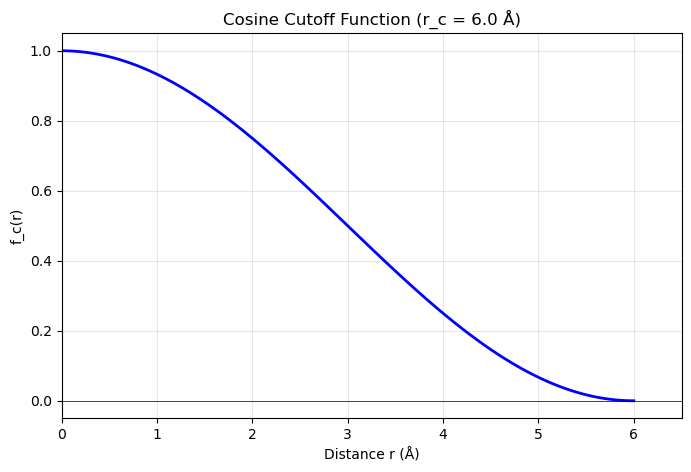

In [9]:
# The cosine cutoff ensures smooth decay
r = np.linspace(0, 6, 100)
rc = 6.0

def cutoff(r, rc):
    fc = np.zeros_like(r)
    mask = r < rc
    fc[mask] = 0.5 * (np.cos(np.pi * r[mask] / rc) + 1.0)
    return fc

plt.figure(figsize=(8, 5))
plt.plot(r, cutoff(r, rc), 'b-', lw=2)
plt.xlabel('Distance r (Å)')
plt.ylabel('f_c(r)')
plt.title('Cosine Cutoff Function (r_c = 6.0 Å)')
plt.axhline(y=0, color='k', linestyle='-', lw=0.5)
plt.grid(True, alpha=0.3)
plt.xlim(0, 6.5)
plt.show()

## 9. Stored Results

In [10]:
# Results are stored on the atoms object
atoms = bulk("Cu", "fcc", cubic=True).repeat(2)
pyscal3.find_neighbors(atoms, method="cutoff", cutoff=6.0)
pyscal3.symmetry_functions(atoms, cutoff=6.0)

print("Stored in atoms.arrays:")
print(f"  pyscal_acsf shape: {atoms.arrays['pyscal_acsf'].shape}")

print("\nStored in atoms.info['pyscal_acsf_params']:")
for key, val in atoms.info['pyscal_acsf_params'].items():
    if not isinstance(val, list) or len(val) < 5:
        print(f"  {key}: {val}")
    else:
        print(f"  {key}: [{val[0]}, {val[1]}, ... ({len(val)} items)]")

Stored in atoms.arrays:
  pyscal_acsf shape: (32, 16)

Stored in atoms.info['pyscal_acsf_params']:
  cutoff: 6.0
  g2_params: [(0.001, 0.0), (0.01, 0.0), ... (8 items)]
  g4_params: [(0.001, 1, 1), (0.001, 1, -1), ... (8 items)]
  g5_params: None
  element_types: [np.int64(29)]
  n_features: 16
